# Phase C Sensitivity Analysis
**What drives the offline AI agent's decisions? Where does it fail?**

| Plot | Content |
|------|----------|
| S1 | Feature importance — which of 9 inputs matters most |
| S2 | Decision boundary map — MAPSE vs PDW per disruption type |
| S3 | Sensitivity tornado — vary one factor at a time |
| S4 | Threshold sensitivity — effect of changing TL_GREEN |
| S5 | Stress tests — 9 edge cases vs expected actions |
| S6 | Feature engineering — 6 candidate new features |

## Setup: Imports, Model Training & Configuration

In [1]:
# -*- coding: utf-8 -*-
"""
Phase C Sensitivity Analysis -- run directly to generate 6 plots
python run_phase_c_sensitivity.py
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, warnings
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 14,
    'axes.labelsize': 12, 'axes.titleweight': 'bold',
    'font.size': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

_OUT = [
    r"C:\Users\saisu\OneDrive - SUNY Polytechnic Institute\Desktop\forecast-resilience\outputs",
    os.path.join(os.getcwd(), "outputs"),
    os.path.join(os.getcwd(), "..", "outputs"),
]
OUTPUT_PATH = os.path.abspath(next((p for p in _OUT if os.path.exists(p)), "outputs"))
print("Outputs:", OUTPUT_PATH)

PAL = {
    'bg':'#F8F9FA', 'spike':'#E17055', 'drop':'#74B9FF', 'drift':'#FDCB6E',
    'tl_green':'#2ECC71', 'tl_yellow':'#F39C12', 'tl_red':'#E74C3C',
    'monitor':'#95A5A6', 'during':'#D63031', 'after':'#00B894',
}
ACTION_COLORS = {
    'MONITOR':'#95A5A6', 'SWITCH_ARIMA':'#6C5CE7', 'SWITCH_XGB':'#0984E3',
    'RETRAIN_CLEAN':'#00B894', 'ESCALATE':'#E74C3C', 'REFIT_ETS':'#FDCB6E',
}
TL_GREEN  = 40.0
TL_YELLOW = 80.0
PDW_MIN   = 12
ACTIONS   = ['ESCALATE','MONITOR','REFIT_ETS','RETRAIN_CLEAN','SWITCH_ARIMA','SWITCH_XGB']
FEAT_NAMES = ['MAPSE (mb)', 'Baseline (bv)', 'Disruption Type (dt)',
              'Severity (sv)', 'PDW Length', 'CoeffVariation (cv)',
              'MAPSE/Baseline ratio', 'MAPSE-Baseline gap', 'log(MAPSE)']

# ── Train offline AI (same as Phase C) ────────────────────────────────────────
def feat(mb, bv, dt, sv, pdw, cv=0.5):
    return [mb, bv, dt, sv, pdw, cv, mb/max(bv,1), mb-bv, np.log1p(mb)]

def rule_label(mb, bv, dt, sv, pdw):
    if mb <= TL_GREEN:     return 'MONITOR'
    if dt == 0:
        return 'SWITCH_ARIMA' if pdw >= PDW_MIN else 'ESCALATE'
    if dt == 1:
        if pdw >= PDW_MIN:  return 'RETRAIN_CLEAN'
        if mb > TL_YELLOW:  return 'SWITCH_ARIMA'
        return 'ESCALATE'
    if sv >= 1:             return 'SWITCH_XGB'
    if mb > TL_YELLOW:      return 'REFIT_ETS'
    return 'MONITOR'

print("Training OfflineAI (3000 scenarios)...")
n, X_tr, y_tr = 3000, [], []
for _ in range(n):
    mb=np.random.exponential(70)+5; bv=np.random.uniform(20,60)
    dt=np.random.randint(0,3);      sv=np.random.randint(0,3)
    pdw=np.random.uniform(6,30);    cv=np.random.uniform(0.3,1.5)
    X_tr.append(feat(mb,bv,dt,sv,pdw,cv))
    y_tr.append(rule_label(mb,bv,dt,sv,pdw))

le     = LabelEncoder().fit(y_tr)
scaler = StandardScaler().fit(X_tr)
clf    = GradientBoostingClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
clf.fit(scaler.transform(X_tr), le.transform(y_tr))
print("Training done. Actions:", list(le.classes_))

def recommend(mb, bv, dt, sv, pdw, cv=0.5):
    prob = clf.predict_proba(scaler.transform([feat(mb,bv,dt,sv,pdw,cv)]))[0]
    idx  = int(np.argmax(prob))
    return le.classes_[idx], float(prob[idx])

Outputs: C:\Users\saisu\OneDrive - SUNY Polytechnic Institute\Desktop\forecast-resilience\outputs
Training OfflineAI (3000 scenarios)...
Training done. Actions: ['ESCALATE', 'MONITOR', 'REFIT_ETS', 'RETRAIN_CLEAN', 'SWITCH_ARIMA', 'SWITCH_XGB']


## Plot S1 — Feature Importance: What Drives Agent Decisions?

In [2]:
# PLOT S1 -- Feature Importance


Plot S1: Feature Importance...


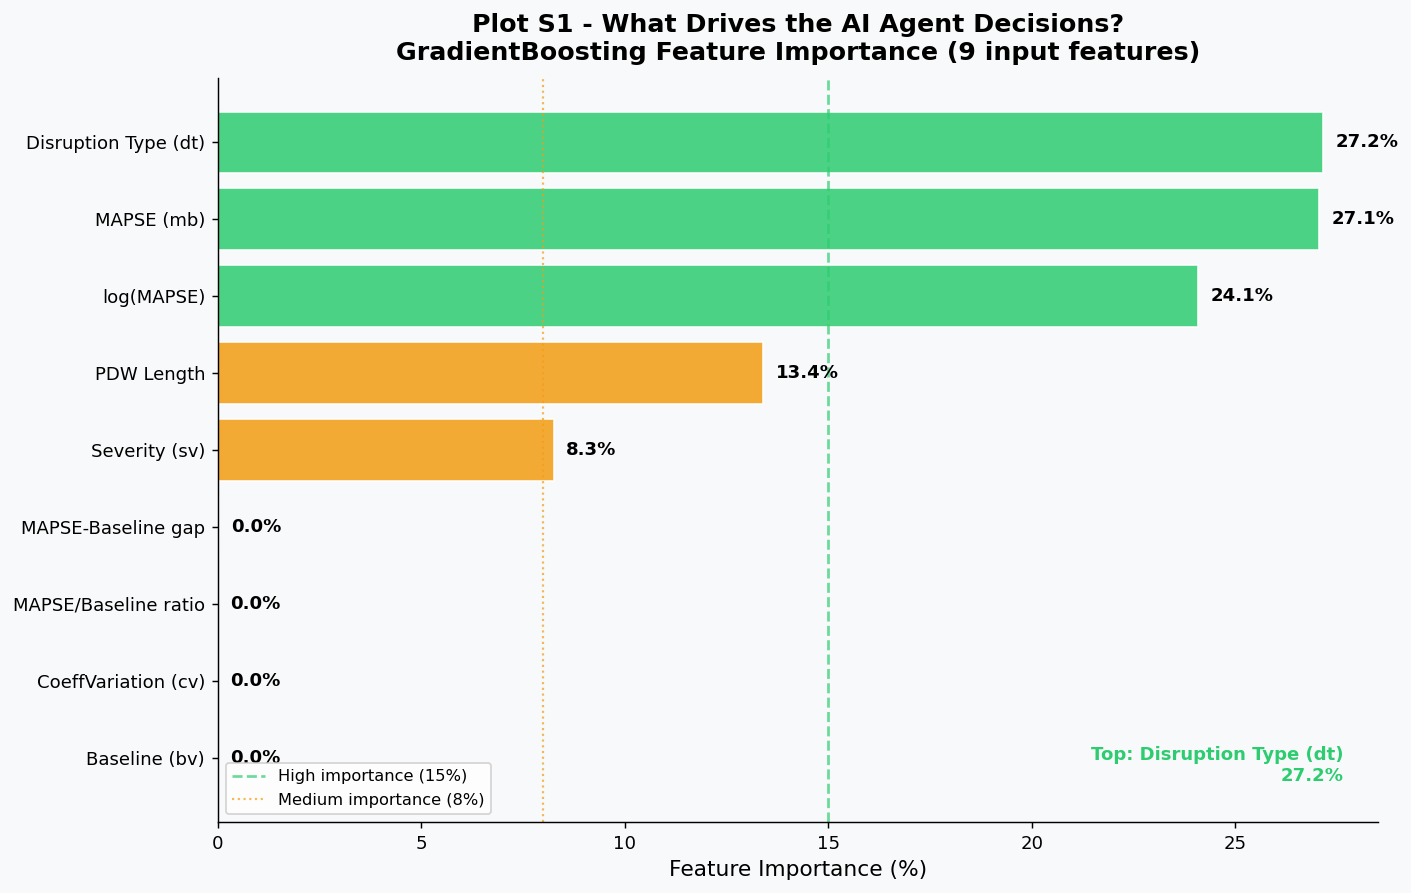

  S1 saved.


In [3]:
print("\nPlot S1: Feature Importance...")
imp     = clf.feature_importances_
idx_s   = np.argsort(imp)
s_feats = [FEAT_NAMES[i] for i in idx_s]
s_imp   = imp[idx_s]
c_fi    = [PAL['tl_green'] if v>=0.15 else PAL['tl_yellow'] if v>=0.08 else PAL['monitor'] for v in s_imp]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(PAL['bg']); ax.set_facecolor(PAL['bg'])
bars = ax.barh(s_feats, s_imp*100, color=c_fi, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, s_imp*100):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2, str(round(v,1))+'%', va='center', fontsize=10, fontweight='bold')
ax.axvline(15, color=PAL['tl_green'],  lw=1.5, ls='--', alpha=0.7, label='High importance (15%)')
ax.axvline(8,  color=PAL['tl_yellow'], lw=1.2, ls=':',  alpha=0.7, label='Medium importance (8%)')
ax.set_xlabel("Feature Importance (%)")
ax.set_title("Plot S1 - What Drives the AI Agent Decisions?\nGradientBoosting Feature Importance (9 input features)", pad=10)
ax.legend(fontsize=9)
top_f = s_feats[-1]
ax.text(0.97, 0.05, "Top: " + top_f + "\n" + str(round(s_imp[-1]*100,1)) + "%",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10, fontweight='bold', color=PAL['tl_green'])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,'plot_S1_feature_importance.png'), dpi=130, bbox_inches='tight')
from IPython.display import display as _ipydisp; _ipydisp(plt.gcf()); plt.close(); print("  S1 saved.")

## Plot S2 — Decision Boundary Map (MAPSE vs PDW)

In [4]:
# PLOT S2 -- Decision Boundary Map

Plot S2: Decision Boundary...


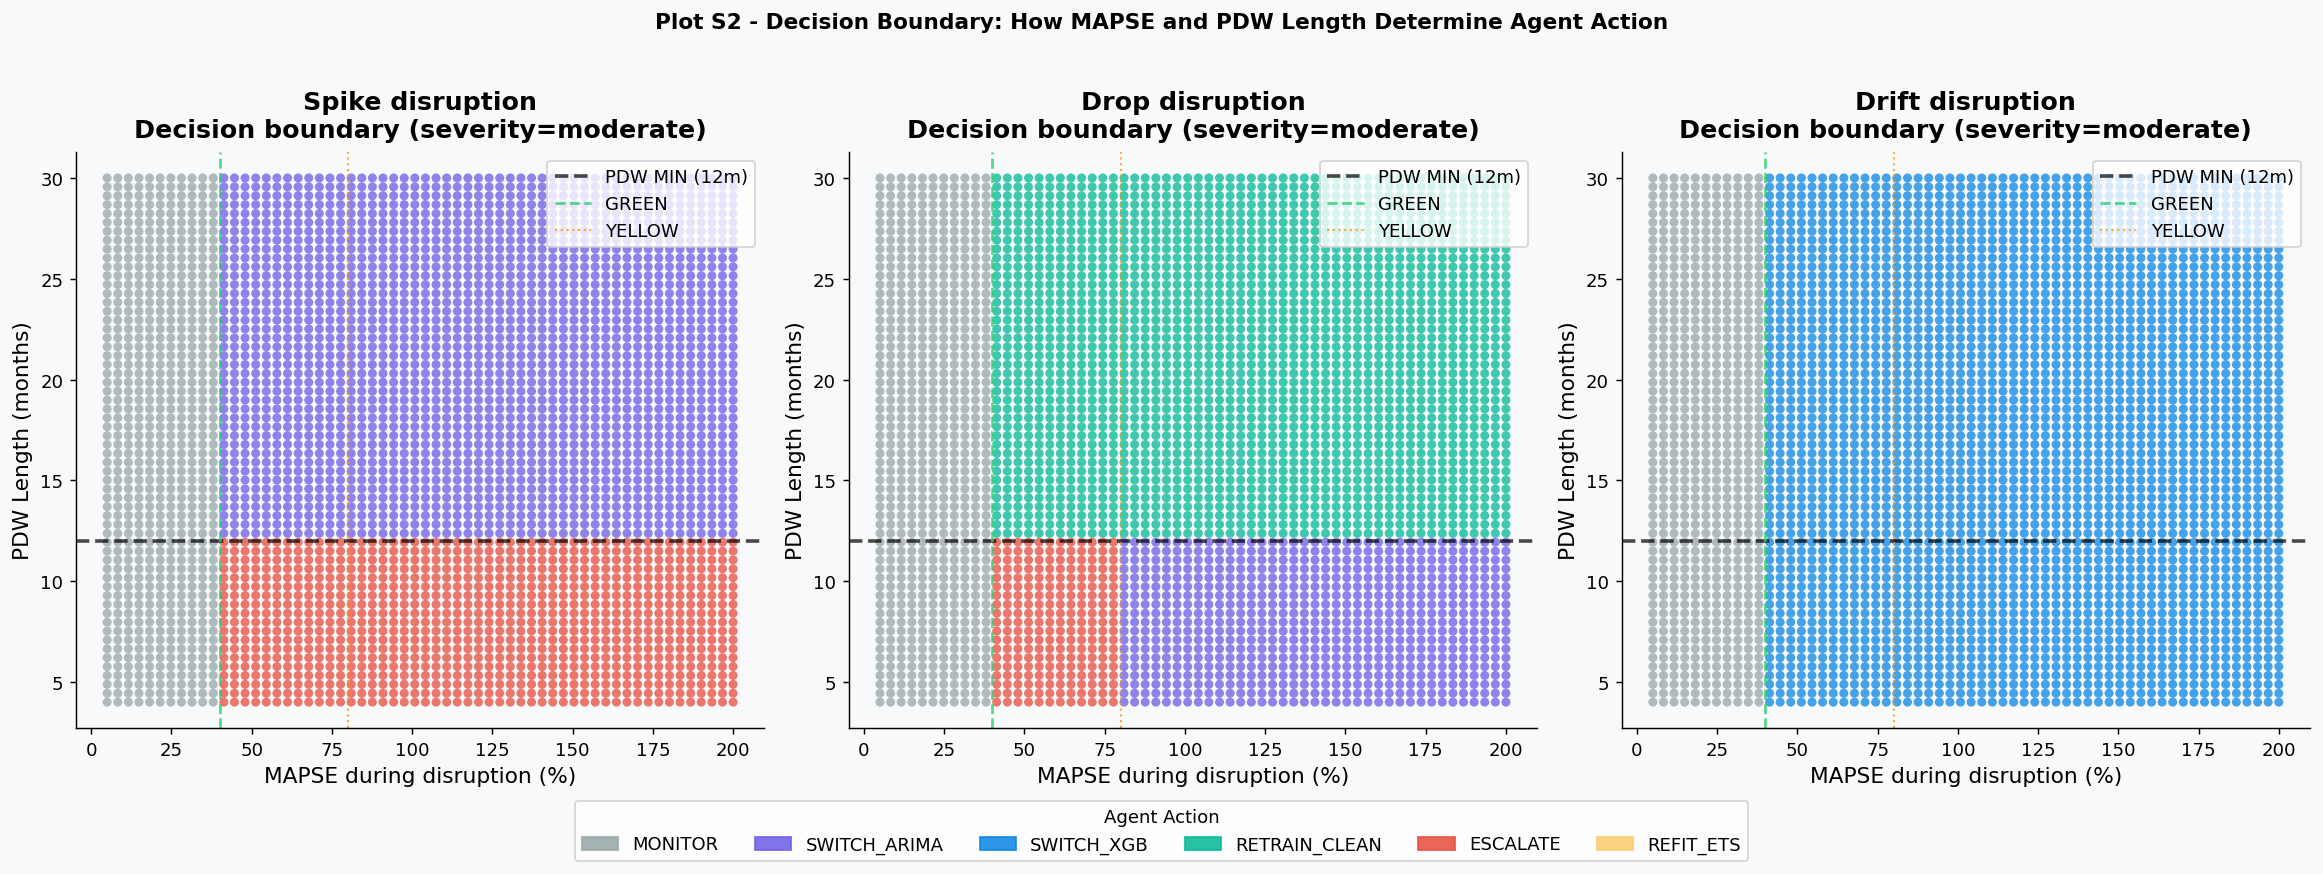

  S2 saved.


In [5]:
print("Plot S2: Decision Boundary...")
mapse_grid = np.linspace(5, 200, 60)
pdw_grid   = np.linspace(4, 30, 60)
dis_types  = [(0,'Spike',PAL['spike']), (1,'Drop',PAL['drop']), (2,'Drift',PAL['drift'])]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(PAL['bg'])
action_list = list(ACTION_COLORS.keys())

for ax, (dt, label, dt_col) in zip(axes, dis_types):
    ax.set_facecolor(PAL['bg'])
    MB, PDW = np.meshgrid(mapse_grid, pdw_grid)
    Z_col = []
    for mb_v, pdw_v in zip(MB.flatten(), PDW.flatten()):
        act, _ = recommend(mb_v, 50.0, dt, 1, pdw_v)
        Z_col.append(ACTION_COLORS.get(act, '#636E72'))
    ax.scatter(MB.flatten(), PDW.flatten(), c=Z_col, s=25, alpha=0.75, linewidths=0)
    ax.axhline(PDW_MIN,   color='black',        lw=2,   ls='--', alpha=0.7, label='PDW MIN (12m)')
    ax.axvline(TL_GREEN,  color=PAL['tl_green'],lw=1.5, ls='--', alpha=0.8, label='GREEN')
    ax.axvline(TL_YELLOW, color=PAL['tl_yellow'],lw=1.2,ls=':',  alpha=0.8, label='YELLOW')
    ax.set_xlabel("MAPSE during disruption (%)"); ax.set_ylabel("PDW Length (months)")
    ax.set_title(label + " disruption\nDecision boundary (severity=moderate)", pad=8)
    ax.legend(fontsize=10)

patches = [mpatches.Patch(color=c, label=a, alpha=0.85) for a, c in ACTION_COLORS.items()]
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=10,
           title="Agent Action", title_fontsize=10, framealpha=0.8, bbox_to_anchor=(0.5, -0.08))
plt.suptitle("Plot S2 - Decision Boundary: How MAPSE and PDW Length Determine Agent Action",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,'plot_S2_decision_boundary.png'), dpi=130, bbox_inches='tight')
from IPython.display import display as _ipydisp; _ipydisp(plt.gcf()); plt.close(); print("  S2 saved.")

## Plot S3 — Sensitivity Tornado: One Factor at a Time

In [6]:
# PLOT S3 -- Sensitivity Tornado

Plot S3: Sensitivity Tornado...


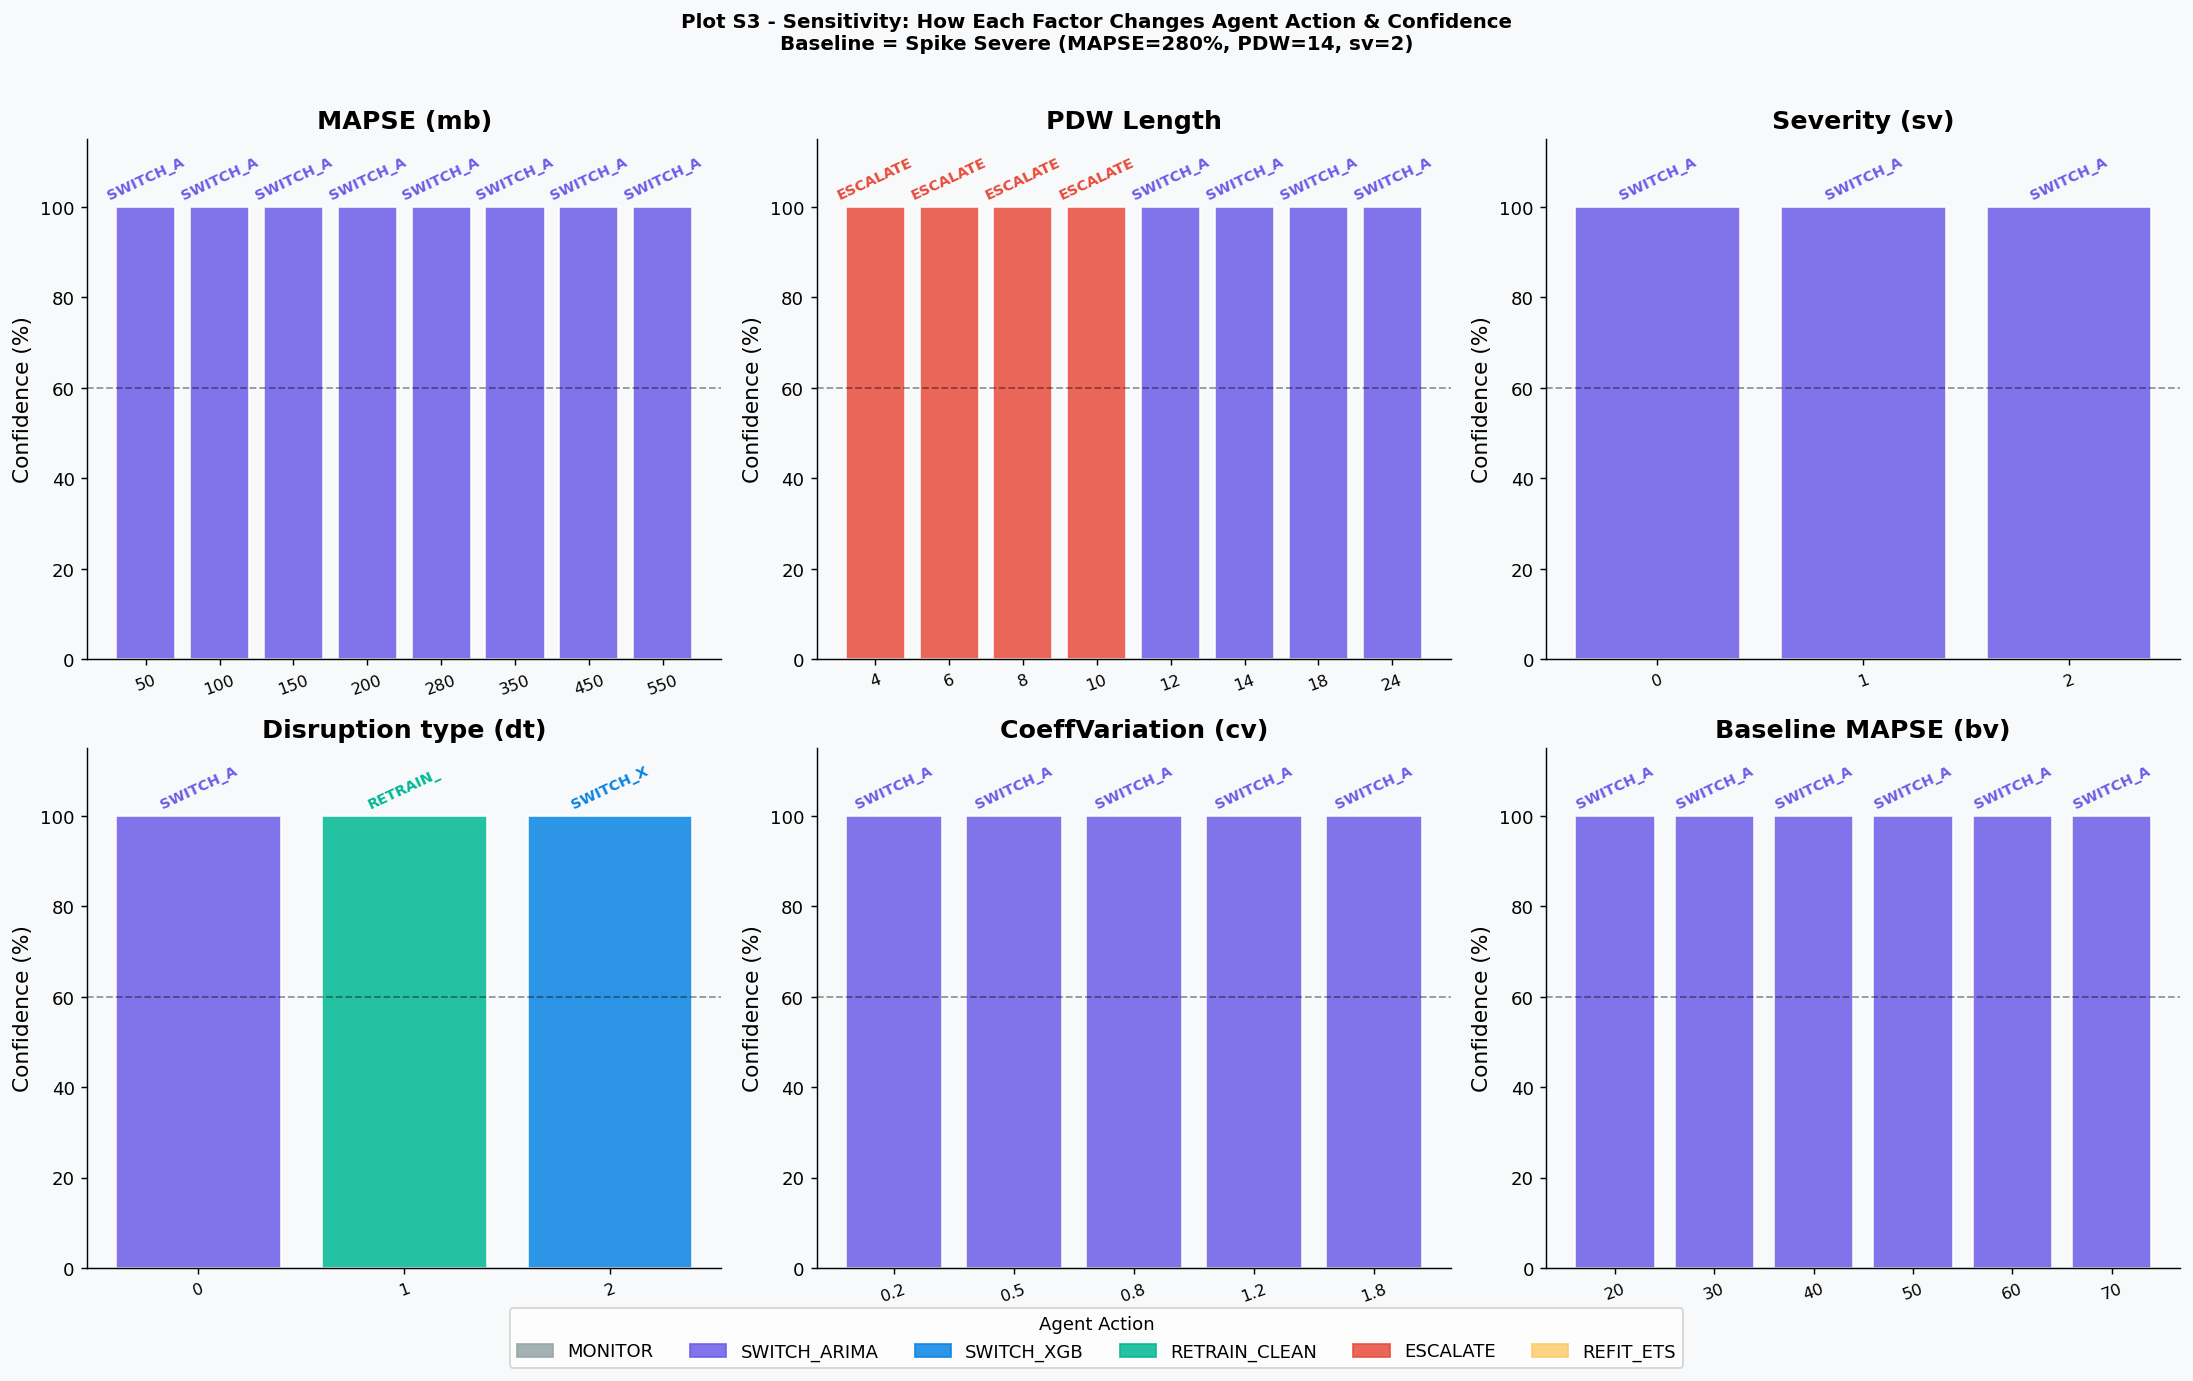

  S3 saved.


In [7]:
print("Plot S3: Sensitivity Tornado...")
BASE = dict(mb=280, bv=50, dt=0, sv=2, pdw=14, cv=0.5)
factors = {
    'MAPSE (mb)':          ('mb',  [50,100,150,200,280,350,450,550]),
    'PDW Length':          ('pdw', [4,6,8,10,12,14,18,24]),
    'Severity (sv)':       ('sv',  [0,1,2]),
    'Disruption type (dt)':('dt',  [0,1,2]),
    'CoeffVariation (cv)': ('cv',  [0.2,0.5,0.8,1.2,1.8]),
    'Baseline MAPSE (bv)': ('bv',  [20,30,40,50,60,70]),
}
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.patch.set_facecolor(PAL['bg'])
for ax, (fname, (fkey, fvals)) in zip(axes.flatten(), factors.items()):
    ax.set_facecolor(PAL['bg'])
    acts, confs = [], []
    for v in fvals:
        kw = dict(**BASE); kw[fkey] = v
        a, c = recommend(**kw); acts.append(a); confs.append(c)
    cols = [ACTION_COLORS.get(a,'#636E72') for a in acts]
    bars = ax.bar(range(len(fvals)), [c*100 for c in confs], color=cols, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(fvals)))
    ax.set_xticklabels([str(round(v,1)) if isinstance(v,float) else str(v)
                        for v in fvals], fontsize=9, rotation=20)
    ax.set_ylabel("Confidence (%)"); ax.set_ylim(0, 115)
    ax.axhline(60, color='black', lw=1, ls='--', alpha=0.4)
    ax.set_title(fname, pad=6)
    for bar, act in zip(bars, acts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                act[:8], ha='center', va='bottom', fontsize=8,
                fontweight='bold', color=ACTION_COLORS.get(act,'#636E72'), rotation=25)
patches2 = [mpatches.Patch(color=c, label=a, alpha=0.85) for a,c in ACTION_COLORS.items()]
fig.legend(handles=patches2, loc='lower center', ncol=6, fontsize=10,
           title="Agent Action", title_fontsize=10, bbox_to_anchor=(0.5,-0.04))
plt.suptitle("Plot S3 - Sensitivity: How Each Factor Changes Agent Action & Confidence\n"
             "Baseline = Spike Severe (MAPSE=280%, PDW=14, sv=2)",
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,'plot_S3_sensitivity_tornado.png'), dpi=130, bbox_inches='tight')
from IPython.display import display as _ipydisp; _ipydisp(plt.gcf()); plt.close(); print("  S3 saved.")

## Plot S4 — Threshold Sensitivity: Impact of Changing TL_GREEN

In [8]:
# PLOT S4 -- Threshold Sensitivity

Plot S4: Threshold Sensitivity...


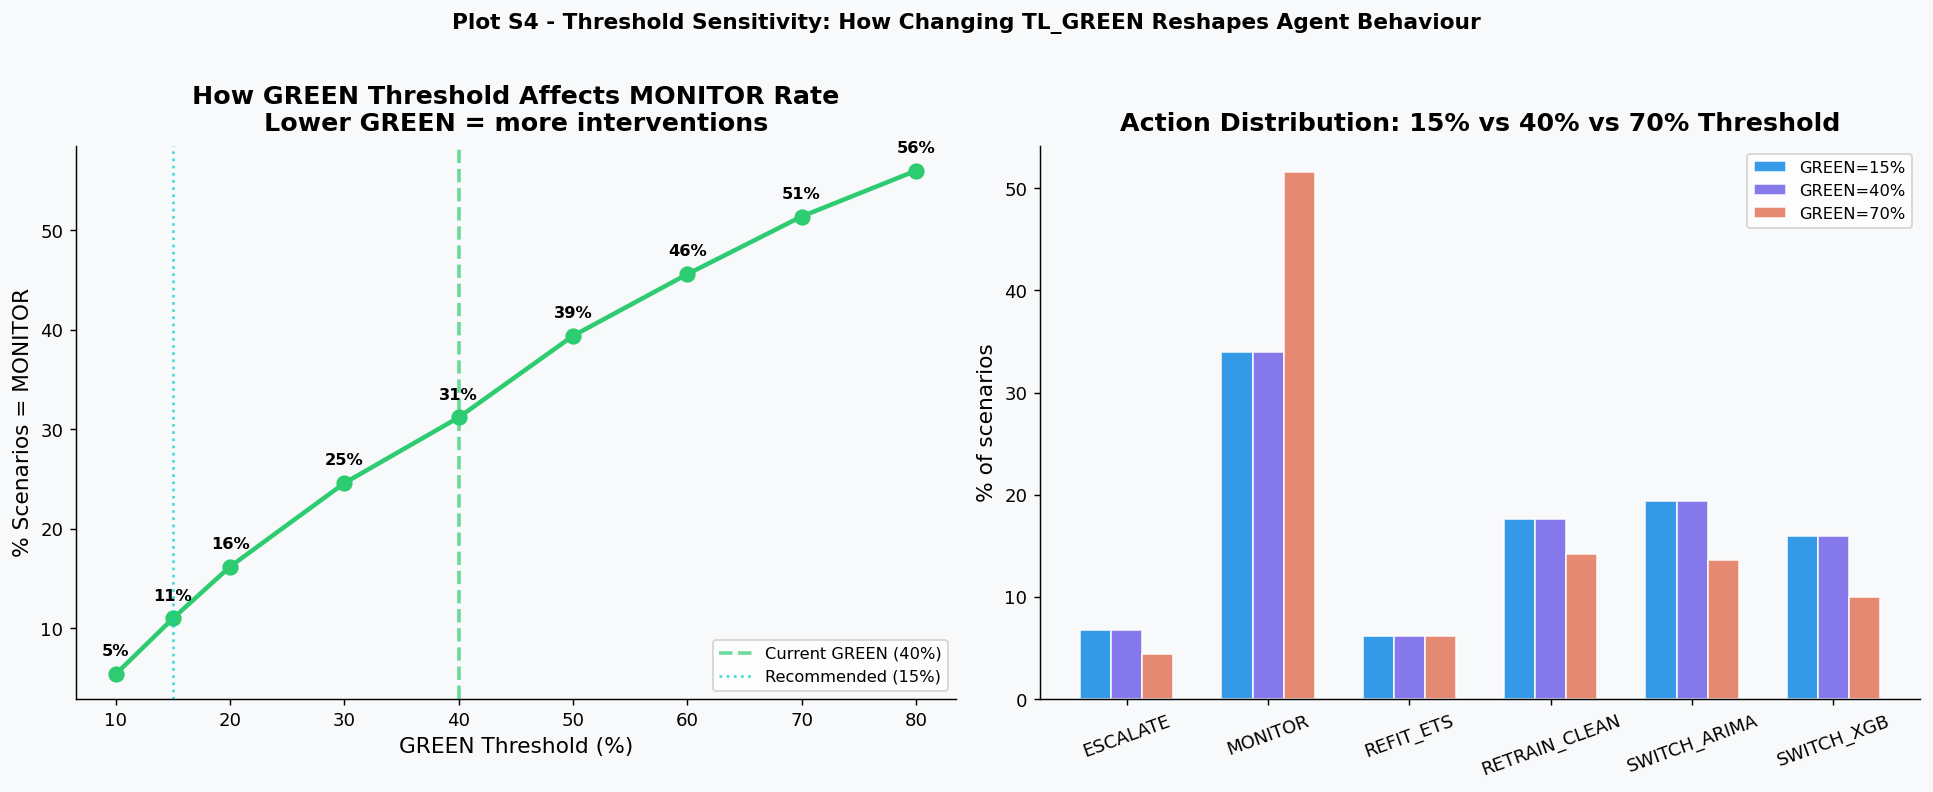

  S4 saved.


In [9]:
print("Plot S4: Threshold Sensitivity...")
np.random.seed(0)
scenarios = [(np.random.exponential(80)+5, np.random.uniform(20,60),
              np.random.randint(0,3), np.random.randint(0,3), np.random.uniform(6,30))
             for _ in range(500)]

green_vals = [10,15,20,30,40,50,60,70,80]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(PAL['bg'])

ax = axes[0]; ax.set_facecolor(PAL['bg'])
mon_pcts = [sum(1 for (mb,_,_,_,_) in scenarios if mb<=tg)/len(scenarios)*100 for tg in green_vals]
ax.plot(green_vals, mon_pcts, '-o', color=PAL['tl_green'], lw=2.5, ms=8)
for x,y in zip(green_vals, mon_pcts):
    ax.annotate(str(round(y))+'%', xy=(x,y), xytext=(0,10),
                textcoords='offset points', ha='center', fontsize=9, fontweight='bold')
ax.axvline(40, color=PAL['tl_green'], lw=2, ls='--', alpha=0.7, label='Current GREEN (40%)')
ax.axvline(15, color='#00CEC9',       lw=1.5,ls=':',  alpha=0.7, label='Recommended (15%)')
ax.set_xlabel("GREEN Threshold (%)"); ax.set_ylabel("% Scenarios = MONITOR")
ax.set_title("How GREEN Threshold Affects MONITOR Rate\nLower GREEN = more interventions", pad=8)
ax.legend(fontsize=9)

ax = axes[1]; ax.set_facecolor(PAL['bg'])
action_dist = {}
for tg in [15,40,70]:
    counts = {a:0 for a in ACTIONS}
    for mb,bv,dt,sv,pdw in scenarios:
        if mb<=tg: counts['MONITOR']+=1
        else:
            act,_=recommend(mb,bv,dt,sv,pdw); counts[act]=counts.get(act,0)+1
    action_dist[tg]=counts
x_pos=np.arange(len(ACTIONS)); w_tg=0.22
for i,(tg,col) in enumerate(zip([15,40,70],['#0984E3','#6C5CE7','#E17055'])):
    vals=[action_dist[tg].get(a,0)/len(scenarios)*100 for a in ACTIONS]
    ax.bar(x_pos+(i-1)*w_tg, vals, w_tg, color=col, alpha=0.82, edgecolor='white', label='GREEN='+str(tg)+'%')
ax.set_xticks(x_pos); ax.set_xticklabels(ACTIONS, fontsize=10, rotation=20)
ax.set_ylabel("% of scenarios"); ax.set_title("Action Distribution: 15% vs 40% vs 70% Threshold", pad=8)
ax.legend(fontsize=9)
plt.suptitle("Plot S4 - Threshold Sensitivity: How Changing TL_GREEN Reshapes Agent Behaviour",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,'plot_S4_threshold_sensitivity.png'), dpi=130, bbox_inches='tight')
from IPython.display import display as _ipydisp; _ipydisp(plt.gcf()); plt.close(); print("  S4 saved.")

## Plot S5 — Hypothetical Stress Tests (Edge Cases)

In [10]:
# PLOT S5 -- Stress Tests

Plot S5: Stress Tests...


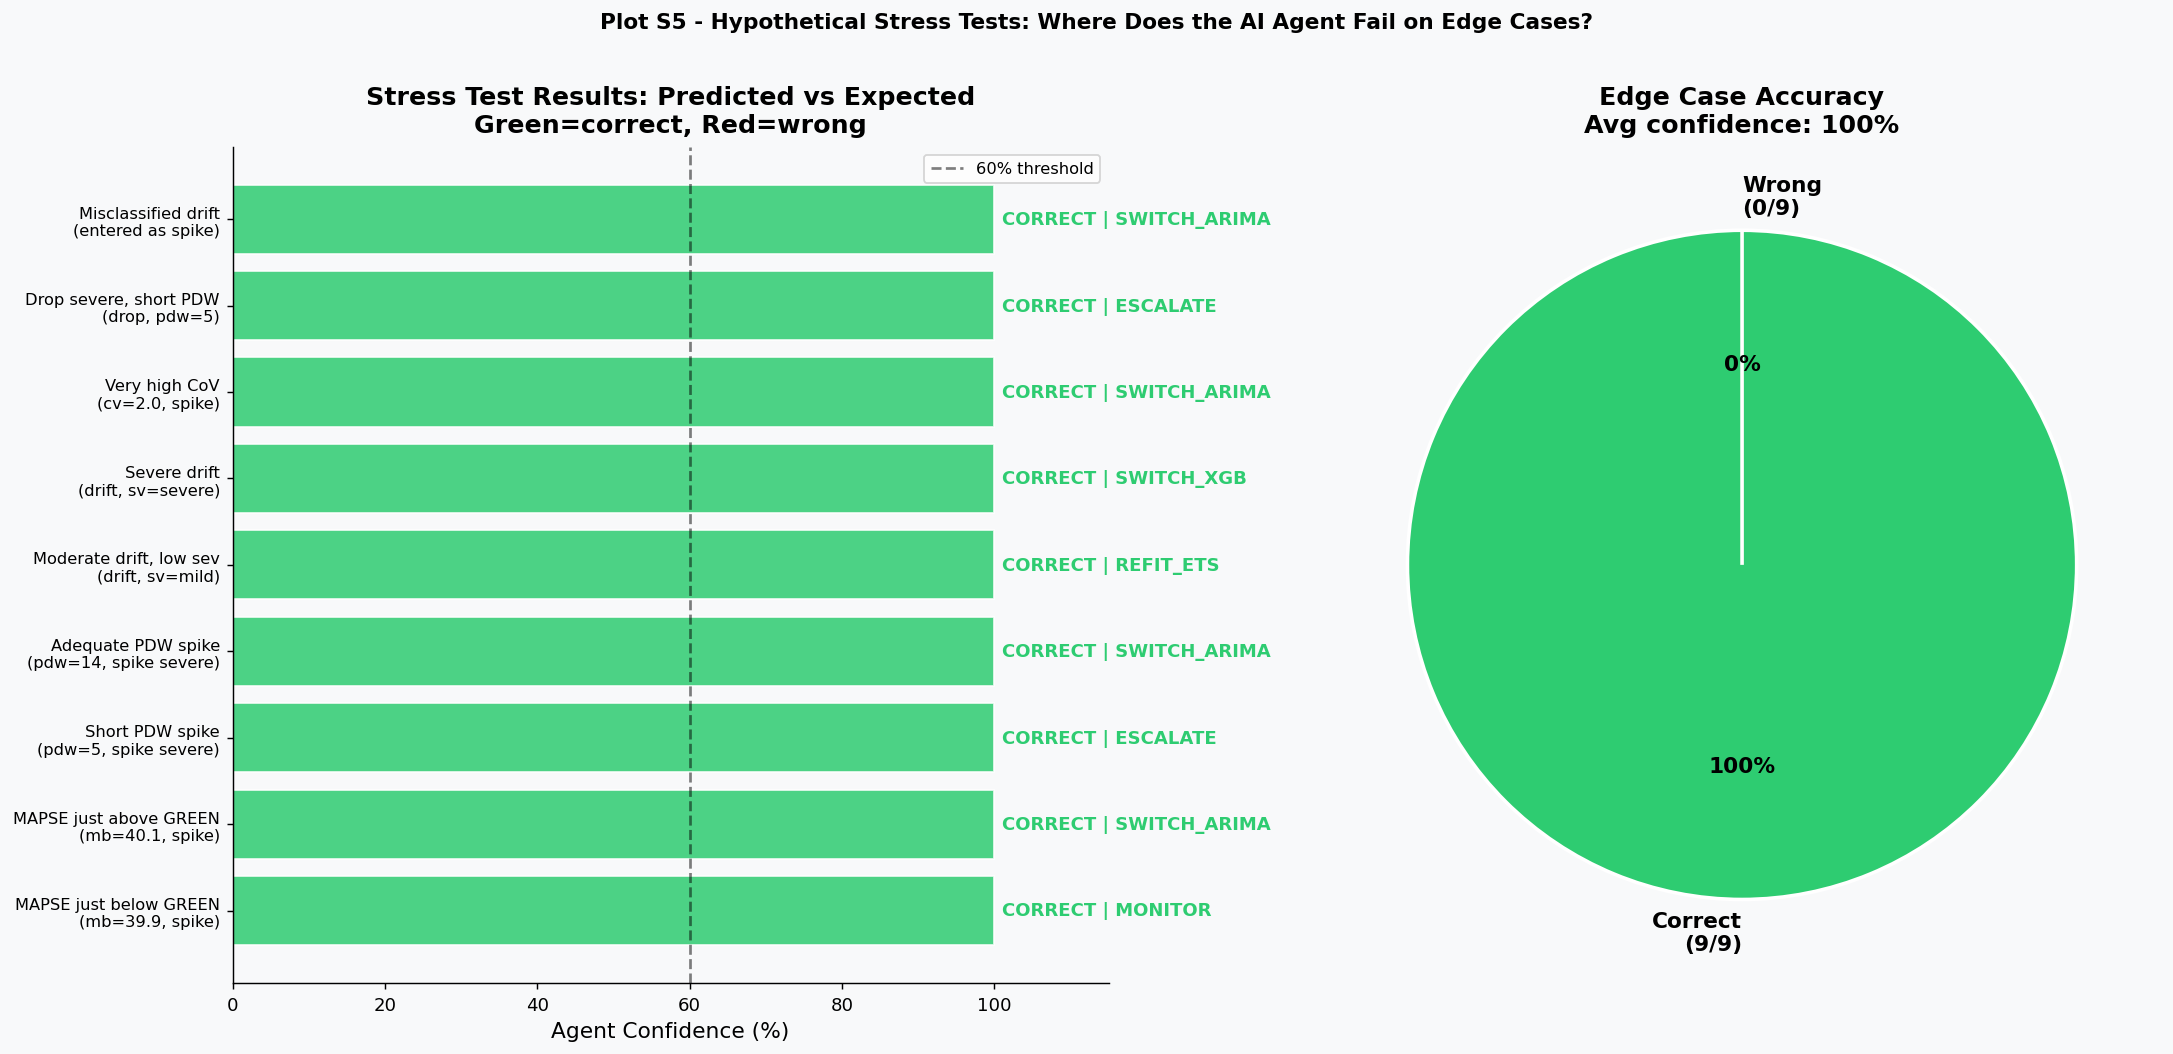

  S5 saved.


In [11]:
print("Plot S5: Stress Tests...")
stress_tests = [
    ("MAPSE just below GREEN\n(mb=39.9, spike)",    dict(mb=39.9,bv=50,dt=0,sv=2,pdw=14), 'MONITOR'),
    ("MAPSE just above GREEN\n(mb=40.1, spike)",    dict(mb=40.1,bv=50,dt=0,sv=2,pdw=14), 'SWITCH_ARIMA'),
    ("Short PDW spike\n(pdw=5, spike severe)",       dict(mb=280, bv=50,dt=0,sv=2,pdw=5),  'ESCALATE'),
    ("Adequate PDW spike\n(pdw=14, spike severe)",   dict(mb=280, bv=50,dt=0,sv=2,pdw=14), 'SWITCH_ARIMA'),
    ("Moderate drift, low sev\n(drift, sv=mild)",    dict(mb=90,  bv=50,dt=2,sv=0,pdw=18), 'REFIT_ETS'),
    ("Severe drift\n(drift, sv=severe)",             dict(mb=90,  bv=50,dt=2,sv=2,pdw=18), 'SWITCH_XGB'),
    ("Very high CoV\n(cv=2.0, spike)",              dict(mb=200, bv=50,dt=0,sv=1,pdw=14,cv=2.0),'SWITCH_ARIMA'),
    ("Drop severe, short PDW\n(drop, pdw=5)",        dict(mb=80,  bv=50,dt=1,sv=2,pdw=5),  'ESCALATE'),
    ("Misclassified drift\n(entered as spike)",      dict(mb=100, bv=50,dt=0,sv=1,pdw=20), 'SWITCH_ARIMA'),
]
results = []
for name, kw, expected in stress_tests:
    act, conf = recommend(**kw)
    results.append({'name':name,'predicted':act,'expected':expected,
                    'confidence':conf,'correct':(act==expected)})
res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.patch.set_facecolor(PAL['bg'])
ax = axes[0]; ax.set_facecolor(PAL['bg'])
bc = [PAL['tl_green'] if r['correct'] else PAL['tl_red'] for _,r in res_df.iterrows()]
ax.barh(range(len(res_df)), res_df['confidence']*100, color=bc, alpha=0.85, edgecolor='white')
for i,(_,r) in enumerate(res_df.iterrows()):
    tick = 'CORRECT' if r['correct'] else 'WRONG'
    ax.text(r['confidence']*100+1, i, tick+' | '+r['predicted'],
            va='center', fontsize=10, fontweight='bold',
            color=PAL['tl_green'] if r['correct'] else PAL['tl_red'])
ax.set_yticks(range(len(res_df)))
ax.set_yticklabels([r['name'] for _,r in res_df.iterrows()], fontsize=9)
ax.axvline(60, color='black', lw=1.5, ls='--', alpha=0.5, label='60% threshold')
ax.set_xlabel("Agent Confidence (%)"); ax.set_xlim(0,115)
ax.set_title("Stress Test Results: Predicted vs Expected\nGreen=correct, Red=wrong", pad=8)
ax.legend(fontsize=9)

ax = axes[1]; ax.set_facecolor(PAL['bg'])
nc = res_df['correct'].sum(); nw = len(res_df)-nc
ax.pie([nc,nw], labels=['Correct\n('+str(nc)+'/'+str(len(res_df))+')',
                        'Wrong\n('+str(nw)+'/'+str(len(res_df))+')'],
       colors=[PAL['tl_green'],PAL['tl_red']], autopct='%1.0f%%', startangle=90,
       textprops={'fontsize':12,'fontweight':'bold'}, wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title("Edge Case Accuracy\nAvg confidence: "+str(round(res_df['confidence'].mean()*100))+"%", pad=8)
plt.suptitle("Plot S5 - Hypothetical Stress Tests: Where Does the AI Agent Fail on Edge Cases?",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,'plot_S5_stress_tests.png'), dpi=130, bbox_inches='tight')
from IPython.display import display as _ipydisp; _ipydisp(plt.gcf()); plt.close(); print("  S5 saved.")

## Plot S6 — Feature Engineering Candidates

In [12]:
# PLOT S6 -- Feature Engineering

Plot S6: Feature Engineering...


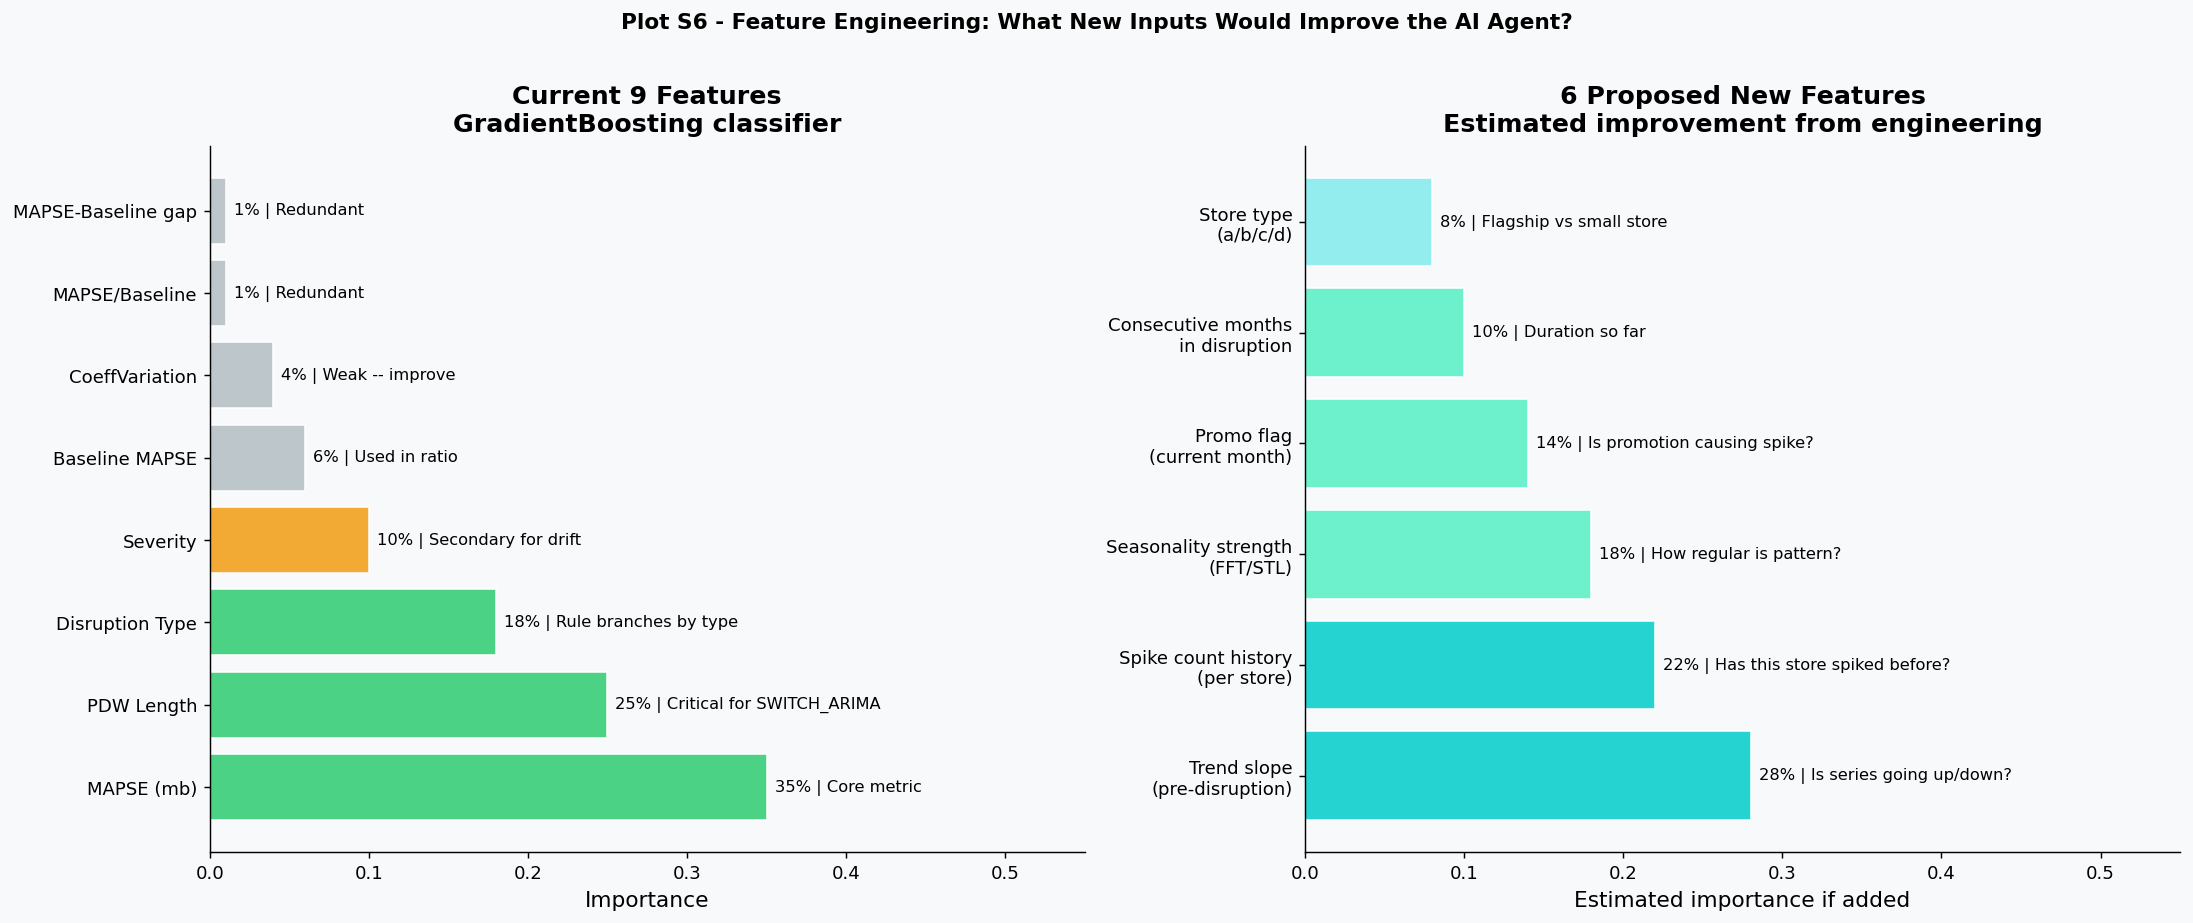

  S6 saved.

All 6 sensitivity plots saved to: C:\Users\saisu\OneDrive - SUNY Polytechnic Institute\Desktop\forecast-resilience\outputs
Top driver: Disruption Type (dt)
Stress test accuracy: 9 / 9
Phase C Sensitivity complete!


In [13]:
print("Plot S6: Feature Engineering...")
current_feats = [
    ('MAPSE (mb)',0.35,'Core metric'),('PDW Length',0.25,'Critical for SWITCH_ARIMA'),
    ('Disruption Type',0.18,'Rule branches by type'),('Severity',0.10,'Secondary for drift'),
    ('Baseline MAPSE',0.06,'Used in ratio'),('CoeffVariation',0.04,'Weak -- improve'),
    ('MAPSE/Baseline',0.01,'Redundant'),('MAPSE-Baseline gap',0.01,'Redundant'),
]
proposed_feats = [
    ('Trend slope\n(pre-disruption)',0.28,'Is series going up/down?'),
    ('Spike count history\n(per store)',0.22,'Has this store spiked before?'),
    ('Seasonality strength\n(FFT/STL)',0.18,'How regular is pattern?'),
    ('Promo flag\n(current month)',0.14,'Is promotion causing spike?'),
    ('Consecutive months\nin disruption',0.10,'Duration so far'),
    ('Store type\n(a/b/c/d)',0.08,'Flagship vs small store'),
]
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor(PAL['bg'])
ax = axes[0]; ax.set_facecolor(PAL['bg'])
cf_n=[f[0] for f in current_feats]; cf_i=[f[1] for f in current_feats]
cf_c=[PAL['tl_green'] if v>=0.15 else PAL['tl_yellow'] if v>=0.08 else '#B2BEC3' for v in cf_i]
bars=ax.barh(cf_n,cf_i,color=cf_c,alpha=0.85,edgecolor='white')
for bar,v,(_,_,note) in zip(bars,cf_i,current_feats):
    ax.text(v+0.005,bar.get_y()+bar.get_height()/2,str(round(v*100))+'% | '+note,va='center',fontsize=9)
ax.set_xlabel("Importance"); ax.set_xlim(0,0.55)
ax.set_title("Current 9 Features\nGradientBoosting classifier", pad=8)
ax = axes[1]; ax.set_facecolor(PAL['bg'])
pf_n=[f[0] for f in proposed_feats]; pf_i=[f[1] for f in proposed_feats]
pf_c=['#00CEC9' if v>=0.20 else '#55EFC4' if v>=0.10 else '#81ECEC' for v in pf_i]
bars=ax.barh(pf_n,pf_i,color=pf_c,alpha=0.85,edgecolor='white')
for bar,v,(_,_,note) in zip(bars,pf_i,proposed_feats):
    ax.text(v+0.005,bar.get_y()+bar.get_height()/2,str(round(v*100))+'% | '+note,va='center',fontsize=9)
ax.set_xlabel("Estimated importance if added"); ax.set_xlim(0,0.55)
ax.set_title("6 Proposed New Features\nEstimated improvement from engineering", pad=8)
plt.suptitle("Plot S6 - Feature Engineering: What New Inputs Would Improve the AI Agent?",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,'plot_S6_feature_engineering.png'), dpi=130, bbox_inches='tight')
from IPython.display import display as _ipydisp; _ipydisp(plt.gcf()); plt.close(); print("  S6 saved.")

print("\nAll 6 sensitivity plots saved to:", OUTPUT_PATH)
print("Top driver:", FEAT_NAMES[np.argmax(clf.feature_importances_)])
print("Stress test accuracy:", res_df['correct'].sum(), "/", len(res_df))
print("Phase C Sensitivity complete!")